

Justificación de Exclusión de Variables
Aquí tienes el resumen para tu documentación sobre por qué eliminamos esas variables específicas por colinealidad:

Nota Metodológica: Eliminación de Variables Redundantes
Tras el análisis de asociación mediante la V de Cramer, se determinó la exclusión de las siguientes variables para evitar la multicolinealidad y reducir la dimensionalidad del modelo sin pérdida de información:

TIPO_ACTIVIDAD: Presentaba una correlación casi perfecta (>0.99) con la variable objetivo SEVERIDAD. Esto ocurre porque el agrupador GRD asigna el tipo de actividad (médica o quirúrgica) basándose en los mismos criterios que definen la severidad del episodio.


TIPO_SERVICIO_SALUD: Presentaba una asociación de 0.99 con REGION. Dado que la red de salud chilena se organiza geográficamente, mantener ambas variables inducía ruido redundante; se optó por conservar REGION por su mayor valor interpretativo en salud pública.


Ojo con un pequeño detalle en la lista que me pegaste: Volviste a incluir TIPO_ACTIVIDAD (13) y TIPO_PROCEDIMIENTO (18), y se te quedó fuera nuestra variable estrella ES_QUIRURGICO (8).

En el código a continuación, he ajustado la lista exactamente a las 22 variables definitivas (sacando las redundantes que acordamos y manteniendo ES_QUIRURGICO). Además, le indico a Pandas explícitamente que no aplique OHE a tus variables objetivo ni a CATEGORIA_CANCER, para que podamos usar esta última para hacer el filtrado limpio durante el Bootstrapping.


Nota Metodológica: Selección de Variables de Intervención
Tras la revisión con la tutoría académica, se determinó priorizar la variable original TIPO_PROCEDIMIENTO sobre la derivada binaria ES_QUIRURGICO.

Aunque ambas presentan una alta asociación estadística, TIPO_PROCEDIMIENTO aporta una mayor riqueza diagnóstica y descriptiva al capturar la complejidad categórica de las intervenciones realizadas. Esta decisión permite al modelo realizar una caracterización más precisa del episodio oncológico, diferenciando niveles de intensidad terapéutica que serían invisibles en una clasificación puramente dicotómica.

En consecuencia, se han excluido por redundancia absoluta:

TIPO_ACTIVIDAD: Capturada por la variable de salida SEVERIDAD.

TIPO_SERVICIO_SALUD: Capturada por la variable geográfica REGION.

Cargando y unificando datasets (2019-2024)...
Dataset unificado con 5.725.670 filas.

Calculando correlación de Spearman para variables numéricas...


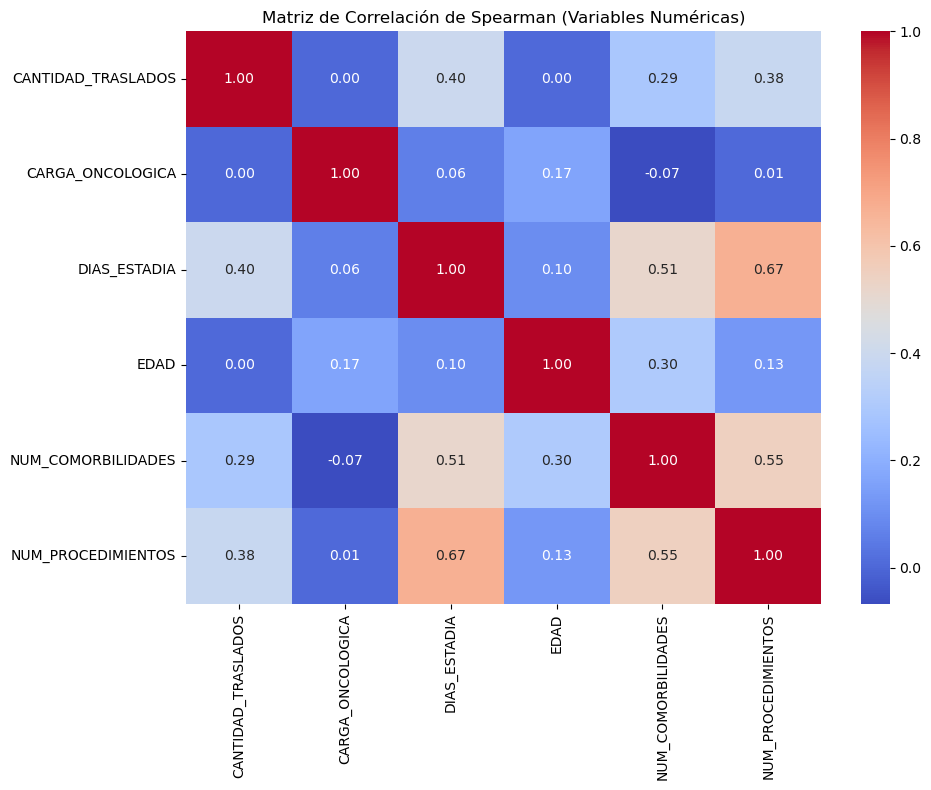


Calculando V de Cramer para variables categóricas (esto puede tardar unos minutos)...


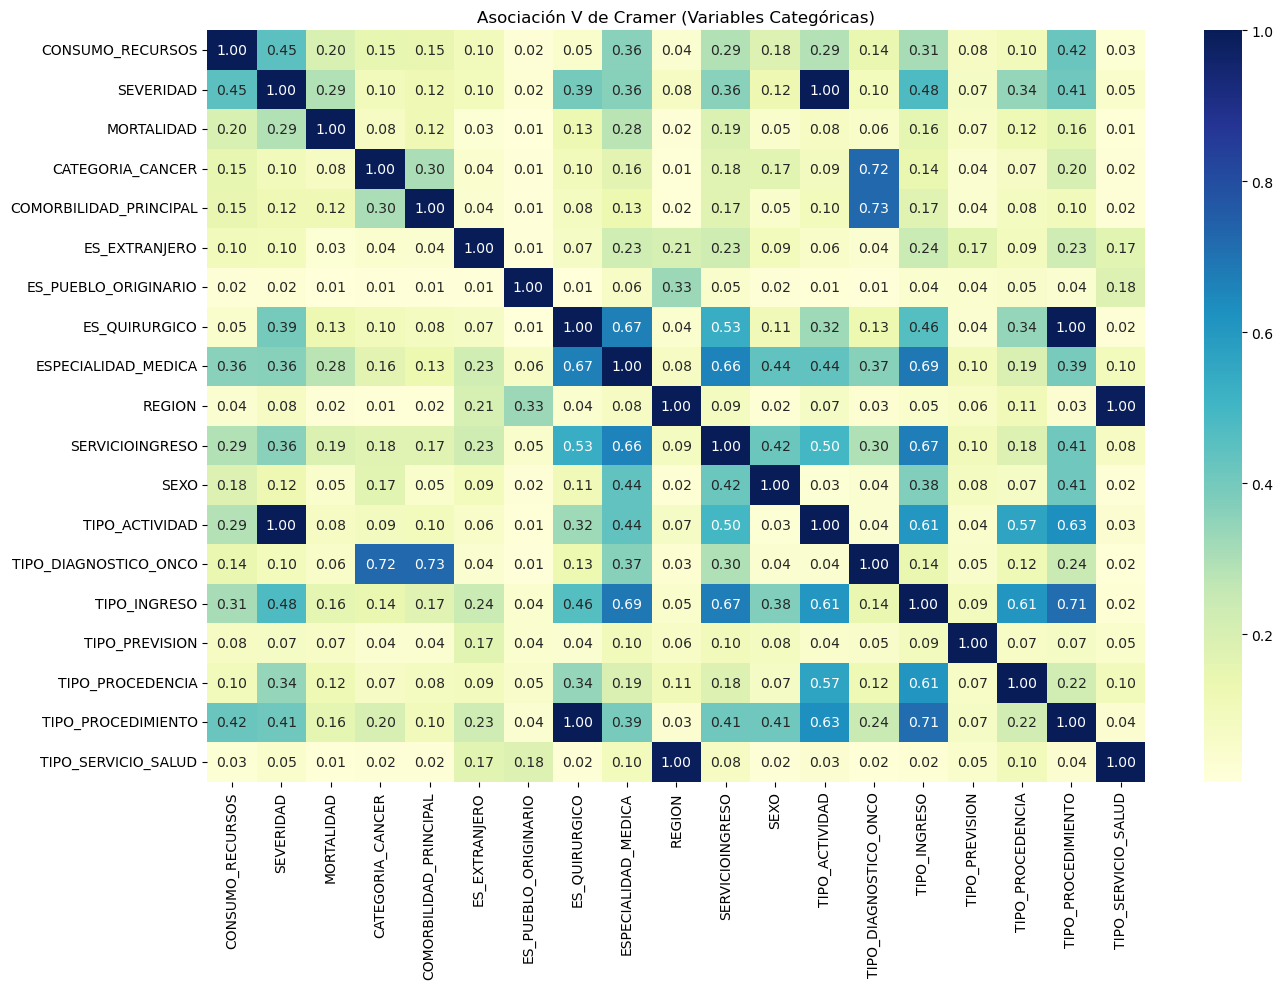


Análisis completado. Archivos guardados en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, chi2_contingency
import os

# 1. Carga y Unificación
carpeta_procesados = "../../Datos/Datos procesados"
dir_salida = "../../Resultados/Resultados (etapa 1 y 2)/Análisis final"

# Crear carpeta de resultados si no existe
os.makedirs(dir_salida, exist_ok=True)

archivos = [f"GRD_PROCESADO_{año}_DERIVADAS.csv" for año in range(2019, 2025)]

print("Cargando y unificando datasets (2019-2024)...")
df_list = []
for f in archivos:
    if os.path.exists(f"{carpeta_procesados}/{f}"):
        temp = pd.read_csv(f"{carpeta_procesados}/{f}", low_memory=False)
        temp['AÑO_DATA'] = int(f.split('_')[2])
        df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
print(f"Dataset unificado con {len(df):,} filas.".replace(',', '.'))

# 2. Definición de Variables
vars_num = ['CANTIDAD_TRASLADOS', 'CARGA_ONCOLOGICA', 'DIAS_ESTADIA', 'EDAD', 'NUM_COMORBILIDADES', 'NUM_PROCEDIMIENTOS']
vars_cat = [
    'CONSUMO_RECURSOS', 'SEVERIDAD', 'MORTALIDAD', 'CATEGORIA_CANCER', 'COMORBILIDAD_PRINCIPAL', 
    'ES_EXTRANJERO', 'ES_PUEBLO_ORIGINARIO', 'ES_QUIRURGICO', 'ESPECIALIDAD_MEDICA', 'REGION', 
    'SERVICIOINGRESO', 'SEXO', 'TIPO_ACTIVIDAD', 'TIPO_DIAGNOSTICO_ONCO', 'TIPO_INGRESO', 
    'TIPO_PREVISION', 'TIPO_PROCEDENCIA', 'TIPO_PROCEDIMIENTO', 'TIPO_SERVICIO_SALUD'
]

# --- A. Correlación Numérica (Spearman) ---
print("\nCalculando correlación de Spearman para variables numéricas...")
corr_num = df[vars_num].corr(method='spearman')

# Guardar CSV
corr_num.to_csv(f"{dir_salida}/Matriz_Correlacion_Spearman.csv", encoding='utf-8-sig')

# Graficar y guardar imagen
plt.figure(figsize=(10, 8))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Spearman (Variables Numéricas)")
plt.tight_layout()
plt.savefig(f"{dir_salida}/Heatmap_Spearman.png", dpi=300)
plt.show()

# --- B. Asociación Categórica (V de Cramer) ---
print("\nCalculando V de Cramer para variables categóricas (esto puede tardar unos minutos)...")
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

rows = []
for var1 in vars_cat:
    col = []
    for var2 in vars_cat:
        col.append(cramers_v(df[var1], df[var2]))
    rows.append(col)

v_cramer_matrix = pd.DataFrame(rows, index=vars_cat, columns=vars_cat)

# Guardar CSV
v_cramer_matrix.to_csv(f"{dir_salida}/Matriz_Asociacion_Cramer.csv", encoding='utf-8-sig')

# Graficar y guardar imagen
plt.figure(figsize=(14, 10))
sns.heatmap(v_cramer_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Asociación V de Cramer (Variables Categóricas)")
plt.tight_layout()
plt.savefig(f"{dir_salida}/Heatmap_Cramer.png", dpi=300)
plt.show()

print(f"\nAnálisis completado. Archivos guardados en: {dir_salida}")

In [1]:
import pandas as pd
import os
import gc

# 1. Configuración de rutas
dir_entrada = "../../Datos/Datos procesados"
dir_salida = "../../Datos/Datasets Finales"
os.makedirs(dir_salida, exist_ok=True)

columnas_a_cargar = [
    'CONSUMO_RECURSOS', 'SEVERIDAD', 'MORTALIDAD', 'CATEGORIA_CANCER',
    'COMORBILIDAD_PRINCIPAL', 'ES_EXTRANJERO', 'ES_PUEBLO_ORIGINARIO', 
    'TIPO_PROCEDIMIENTO', 'ESPECIALIDAD_MEDICA', 'REGION', 'SERVICIOINGRESO', 
    'SEXO', 'TIPO_DIAGNOSTICO_ONCO', 'TIPO_INGRESO', 'TIPO_PREVISION', 
    'TIPO_PROCEDENCIA', 'CANTIDAD_TRASLADOS', 'CARGA_ONCOLOGICA', 
    'DIAS_ESTADIA', 'EDAD', 'NUM_COMORBILIDADES', 'NUM_PROCEDIMIENTOS'
]

# AGREGADO: CATEGORIA_CANCER ahora pasará por One-Hot Encoding
vars_para_ohe = [
    'COMORBILIDAD_PRINCIPAL', 'ES_EXTRANJERO', 'ES_PUEBLO_ORIGINARIO', 
    'TIPO_PROCEDIMIENTO', 'ESPECIALIDAD_MEDICA', 'REGION', 'SERVICIOINGRESO', 
    'SEXO', 'TIPO_DIAGNOSTICO_ONCO', 'TIPO_INGRESO', 'TIPO_PREVISION', 
    'TIPO_PROCEDENCIA', 'CATEGORIA_CANCER' 
]

print("Iniciando procesamiento verdaderamente optimizado (Anti-Colapso de RAM)...")

archivos_train_onco = []
archivos_train_control = []
archivos_test_onco = []
archivos_test_control = []

# PASO 1: Procesar y guardar año por año
for año in range(2019, 2025):
    archivo = f"GRD_PROCESADO_{año}_DERIVADAS.csv"
    ruta = os.path.join(dir_entrada, archivo)
    
    if not os.path.exists(ruta):
        continue
        
    print(f"  -> Procesando {año}...")
    df_temp = pd.read_csv(ruta, usecols=columnas_a_cargar, low_memory=False)
    
    # -------------------------------------------------------------------------
    # TRATAMIENTO DE CATEGORIA_CANCER ANTES DEL OHE
    # Transforma "C15-C26: Órganos digestivos" a "C15_C26"
    # Si es "SIN_CANCER", lo deja igual.
    # -------------------------------------------------------------------------
    df_temp['CATEGORIA_CANCER'] = df_temp['CATEGORIA_CANCER'].astype(str).str.split(':').str[0].str.replace('-', '_').str.strip()
    
    # One-Hot Encoding con drop_first=True (Mantiene la Categoría Base)
    df_temp_ohe = pd.get_dummies(df_temp, columns=vars_para_ohe, drop_first=True)
    df_temp_ohe.columns = df_temp_ohe.columns.str.replace(' ', '_').str.replace('-', '_').str.upper()
    
    # Separar Onco vs Control (Usamos la columna OHE generada para SIN_CANCER o la ausencia de las demás)
    # Como aplicamos drop_first=True y OHE eliminó la columna CATEGORIA_CANCER original,
    # debemos identificar a los pacientes oncológicos sumando las columnas de cáncer generadas.
    columnas_cancer = [col for col in df_temp_ohe.columns if col.startswith('CATEGORIA_CANCER_') and 'SIN_CANCER' not in col]
    
    if len(columnas_cancer) > 0:
        mask_onco = df_temp_ohe[columnas_cancer].sum(axis=1) > 0
    else:
        # Por si en algún año raro no hay ningún cáncer (poco probable)
        mask_onco = pd.Series(False, index=df_temp_ohe.index)
        
    df_onco = df_temp_ohe[mask_onco]
    df_control = df_temp_ohe[~mask_onco]
    
    # Guardar en CSVs temporales
    ruta_onco = os.path.join(dir_salida, f"temp_onco_{año}.csv")
    ruta_control = os.path.join(dir_salida, f"temp_control_{año}.csv")
    
    df_onco.to_csv(ruta_onco, index=False)
    df_control.to_csv(ruta_control, index=False)
    
    if año < 2024:
        archivos_train_onco.append(ruta_onco)
        archivos_train_control.append(ruta_control)
    else:
        archivos_test_onco.append(ruta_onco)
        archivos_test_control.append(ruta_control)
        
    del df_temp, df_temp_ohe, df_onco, df_control
    gc.collect()

# PASO 2: Unificar y alinear columnas sin saturar la RAM
print("\nUnificando y alineando conjuntos de datos bloque por bloque...")

def unificar_y_alinear_seguro(lista_archivos, nombre_salida):
    if not lista_archivos: return
    
    print(f"  [+] Alineando {nombre_salida} de forma segura...")
    
    # 1. Escanear rápidamente TODOS los archivos solo para recolectar las columnas únicas
    todas_las_columnas = set()
    for f in lista_archivos:
        # Leemos solo la fila 0 para obtener los nombres de las columnas sin gastar RAM
        cols = pd.read_csv(f, nrows=0).columns.tolist()
        todas_las_columnas.update(cols)
        
    # Ordenar las columnas para mantener la consistencia en el dataset final
    columnas_maestras = sorted(list(todas_las_columnas))
    ruta_final = os.path.join(dir_salida, nombre_salida)
    
    # 2. Procesar y guardar archivo por archivo
    primer_archivo = True
    total_filas = 0
    
    for f in lista_archivos:
        df_temp = pd.read_csv(f)
        total_filas += len(df_temp)
        
        # Reindexar alinea el dataframe con las columnas maestras.
        # Las columnas de OHE que falten en este año específico se llenarán con 0
        df_temp = df_temp.reindex(columns=columnas_maestras, fill_value=0)
        
        # Si es el primer archivo, escribimos el archivo nuevo con los encabezados
        if primer_archivo:
            df_temp.to_csv(ruta_final, index=False, mode='w', header=True)
            primer_archivo = False
        # Si son los siguientes, agregamos los datos al final del CSV (append) sin encabezados
        else:
            df_temp.to_csv(ruta_final, index=False, mode='a', header=False)
            
        # Limpieza activa por cada iteración
        del df_temp
        gc.collect()

    # 3. Limpiar los archivos temporales de este conjunto
    for f in lista_archivos:
        os.remove(f)
        
    print(f"      -> Guardado exitoso: {nombre_salida} ({total_filas:,} filas, {len(columnas_maestras)} columnas)")

# Ejecutar la unificación segura
unificar_y_alinear_seguro(archivos_train_onco, "dataset_entrenamiento_onco_2019_2023.csv")
unificar_y_alinear_seguro(archivos_train_control, "dataset_entrenamiento_control_2019_2023.csv")
unificar_y_alinear_seguro(archivos_test_onco, "dataset_prueba_onco_2024.csv")
unificar_y_alinear_seguro(archivos_test_control, "dataset_prueba_control_2024.csv")

print("\n¡Proceso completado con éxito! Tu RAM y tu SSD están a salvo.")

Iniciando procesamiento verdaderamente optimizado (Anti-Colapso de RAM)...
  -> Procesando 2019...
  -> Procesando 2020...
  -> Procesando 2021...
  -> Procesando 2022...
  -> Procesando 2023...
  -> Procesando 2024...

Unificando y alineando conjuntos de datos bloque por bloque...
  [+] Alineando dataset_entrenamiento_onco_2019_2023.csv de forma segura...
      -> Guardado exitoso: dataset_entrenamiento_onco_2019_2023.csv (390,632 filas, 113 columnas)
  [+] Alineando dataset_entrenamiento_control_2019_2023.csv de forma segura...
      -> Guardado exitoso: dataset_entrenamiento_control_2019_2023.csv (4,258,693 filas, 113 columnas)
  [+] Alineando dataset_prueba_onco_2024.csv de forma segura...
      -> Guardado exitoso: dataset_prueba_onco_2024.csv (97,128 filas, 113 columnas)
  [+] Alineando dataset_prueba_control_2024.csv de forma segura...
      -> Guardado exitoso: dataset_prueba_control_2024.csv (979,217 filas, 113 columnas)

¡Proceso completado con éxito! Tu RAM y tu SSD están a 

Aleatorio no 2024 evaluacion

In [1]:
import pandas as pd
import numpy as np
import os
import gc
from sklearn.model_selection import train_test_split

# 1. Configuración de rutas
dir_entrada = "../../Datos/Datos procesados"
dir_salida = "../../Datos/Datasets Finales"
os.makedirs(dir_salida, exist_ok=True)

columnas_a_cargar = [
    'CONSUMO_RECURSOS', 'SEVERIDAD', 'MORTALIDAD', 'CATEGORIA_CANCER',
    'COMORBILIDAD_PRINCIPAL', 'ES_EXTRANJERO', 'ES_PUEBLO_ORIGINARIO', 
    'TIPO_PROCEDIMIENTO', 'ESPECIALIDAD_MEDICA', 'REGION', 'SERVICIOINGRESO', 
    'SEXO', 'TIPO_DIAGNOSTICO_ONCO', 'TIPO_INGRESO', 'TIPO_PREVISION', 
    'TIPO_PROCEDENCIA', 'CANTIDAD_TRASLADOS', 'CARGA_ONCOLOGICA', 
    'DIAS_ESTADIA', 'EDAD', 'NUM_COMORBILIDADES', 'NUM_PROCEDIMIENTOS'
]

vars_para_ohe = [
    'COMORBILIDAD_PRINCIPAL', 'ES_EXTRANJERO', 'ES_PUEBLO_ORIGINARIO', 
    'TIPO_PROCEDIMIENTO', 'ESPECIALIDAD_MEDICA', 'REGION', 'SERVICIOINGRESO', 
    'SEXO', 'TIPO_DIAGNOSTICO_ONCO', 'TIPO_INGRESO', 'TIPO_PREVISION', 
    'TIPO_PROCEDENCIA', 'CATEGORIA_CANCER' 
]

print("="*60)
print("INICIANDO MERGE GLOBAL Y SPLIT ESTRATIFICADO (2019-2024)")
print("="*60)

archivos_temporales_onco = []
archivos_temporales_control = []

# PASO 1: Procesar TODO (2019 a 2024) y guardarlo en temporales
for año in range(2019, 2025):
    archivo = f"GRD_PROCESADO_{año}_DERIVADAS.csv"
    ruta = os.path.join(dir_entrada, archivo)
    
    if not os.path.exists(ruta):
        print(f"  -> Archivo no encontrado: {archivo}")
        continue
        
    print(f"  -> Procesando {año}...")
    df_temp = pd.read_csv(ruta, usecols=columnas_a_cargar, low_memory=False)
    
    # Tratamiento de CATEGORIA_CANCER
    df_temp['CATEGORIA_CANCER'] = df_temp['CATEGORIA_CANCER'].astype(str).str.split(':').str[0].str.replace('-', '_').str.strip()
    
    # OHE
    df_temp_ohe = pd.get_dummies(df_temp, columns=vars_para_ohe, drop_first=True)
    df_temp_ohe.columns = df_temp_ohe.columns.str.replace(' ', '_').str.replace('-', '_').str.upper()
    
    # Separar Onco vs Control
    columnas_cancer = [col for col in df_temp_ohe.columns if col.startswith('CATEGORIA_CANCER_') and 'SIN_CANCER' not in col]
    
    if len(columnas_cancer) > 0:
        mask_onco = df_temp_ohe[columnas_cancer].sum(axis=1) > 0
    else:
        mask_onco = pd.Series(False, index=df_temp_ohe.index)
        
    df_onco = df_temp_ohe[mask_onco]
    df_control = df_temp_ohe[~mask_onco]
    
    # Guardar en CSVs temporales
    ruta_onco = os.path.join(dir_salida, f"temp_onco_{año}.csv")
    ruta_control = os.path.join(dir_salida, f"temp_control_{año}.csv")
    
    df_onco.to_csv(ruta_onco, index=False)
    df_control.to_csv(ruta_control, index=False)
    
    archivos_temporales_onco.append(ruta_onco)
    archivos_temporales_control.append(ruta_control)
        
    del df_temp, df_temp_ohe, df_onco, df_control
    gc.collect()

# PASO 2: Unificar temporalmente todos los años
def unir_archivos(lista_archivos):
    """Lee y unifica una lista de CSVs rellenando con ceros las columnas faltantes (OHE)"""
    if not lista_archivos: return pd.DataFrame()
    
    print("      -> Alineando columnas maestras...")
    todas_las_columnas = set()
    for f in lista_archivos:
        cols = pd.read_csv(f, nrows=0).columns.tolist()
        todas_las_columnas.update(cols)
        
    columnas_maestras = sorted(list(todas_las_columnas))
    df_unificado = pd.DataFrame()
    
    for f in lista_archivos:
        df_temp = pd.read_csv(f)
        df_temp = df_temp.reindex(columns=columnas_maestras, fill_value=0)
        df_unificado = pd.concat([df_unificado, df_temp], ignore_index=True)
        os.remove(f) # Borrar temporal
        
    return df_unificado

print("\n[+] Unificando Cohorte Oncológica Global (2019-2024)...")
df_onco_global = unir_archivos(archivos_temporales_onco)

print("[+] Unificando Cohorte Control Global (2019-2024)...")
df_control_global = unir_archivos(archivos_temporales_control)


# PASO 3: SPLIT ALEATORIO ESTRATIFICADO (80/20)
print("\n[+] Realizando Split Estratificado (Garantizando distribución de minoritarias)...")

# Como tu interés principal es el análisis oncológico, la estratificación más crítica
# es que Mortalidad (la clase hiper-minoritaria) no se pierda al dividir.
target_estratificacion = 'MORTALIDAD' 

# 3.1 Split Oncológico
df_onco_train, df_onco_test = train_test_split(
    df_onco_global, 
    test_size=0.20, 
    random_state=42, 
    stratify=df_onco_global[target_estratificacion] # <- LA MAGIA OCURRE AQUÍ
)

# 3.2 Split Control
df_control_train, df_control_test = train_test_split(
    df_control_global, 
    test_size=0.20, 
    random_state=42, 
    stratify=df_control_global[target_estratificacion] # <- LA MAGIA OCURRE AQUÍ
)

# PASO 4: Guardar los nuevos datasets maestros
print("\n[+] Guardando los 4 Datasets Definitivos (Merge Random)...")

df_onco_train.to_csv(os.path.join(dir_salida, "dataset_entrenamiento_onco.csv"), index=False)
df_control_train.to_csv(os.path.join(dir_salida, "dataset_entrenamiento_control.csv"), index=False)
df_onco_test.to_csv(os.path.join(dir_salida, "dataset_prueba_onco.csv"), index=False)
df_control_test.to_csv(os.path.join(dir_salida, "dataset_prueba_control.csv"), index=False)

print(f"      -> Train Onco: {len(df_onco_train):,} filas")
print(f"      -> Test Onco:  {len(df_onco_test):,} filas")
print(f"      -> Train Ctrl: {len(df_control_train):,} filas")
print(f"      -> Test Ctrl:  {len(df_control_test):,} filas")

del df_onco_global, df_control_global, df_onco_train, df_onco_test, df_control_train, df_control_test
gc.collect()

print("\n¡Merge Global y Split Aleatorio Estratificado completados con éxito!")

INICIANDO MERGE GLOBAL Y SPLIT ESTRATIFICADO (2019-2024)
  -> Procesando 2019...
  -> Procesando 2020...
  -> Procesando 2021...
  -> Procesando 2022...
  -> Procesando 2023...
  -> Procesando 2024...

[+] Unificando Cohorte Oncológica Global (2019-2024)...
      -> Alineando columnas maestras...
[+] Unificando Cohorte Control Global (2019-2024)...
      -> Alineando columnas maestras...

[+] Realizando Split Estratificado (Garantizando distribución de minoritarias)...

[+] Guardando los 4 Datasets Definitivos (Merge Random)...
      -> Train Onco: 390,208 filas
      -> Test Onco:  97,552 filas
      -> Train Ctrl: 4,190,328 filas
      -> Test Ctrl:  1,047,582 filas

¡Merge Global y Split Aleatorio Estratificado completados con éxito!


In [2]:
import os
import pandas as pd

# Carpeta donde están los CSV
dir_salida = "../../Datos/Datasets Finales"

# Listar todos los archivos CSV en la carpeta
archivos = [f for f in os.listdir(dir_salida) if f.endswith(".csv")]

# Mostrar columnas de cada archivo
for archivo in archivos:
    ruta = os.path.join(dir_salida, archivo)
    df = pd.read_csv(ruta, nrows=1)  # leer solo una fila para obtener columnas
    print(f"\nArchivo: {archivo}")
    print("Columnas:")
    print(df.columns.tolist())  # muestra todas las columnas como lista

for col in df.columns:
    print(col)


Archivo: dataset_entrenamiento_control_2019_2023.csv
Columnas:
['CANTIDAD_TRASLADOS', 'CARGA_ONCOLOGICA', 'CATEGORIA_CANCER_C15_C26', 'CATEGORIA_CANCER_C30_C39', 'CATEGORIA_CANCER_C40_C41', 'CATEGORIA_CANCER_C43_C44', 'CATEGORIA_CANCER_C45_C49', 'CATEGORIA_CANCER_C50', 'CATEGORIA_CANCER_C51_C58', 'CATEGORIA_CANCER_C60_C63', 'CATEGORIA_CANCER_C64_C68', 'CATEGORIA_CANCER_C69_C72', 'CATEGORIA_CANCER_C73_C75', 'CATEGORIA_CANCER_C76_C80', 'CATEGORIA_CANCER_C81_C96', 'CATEGORIA_CANCER_C97', 'CATEGORIA_CANCER_SIN_CANCER', 'COMORBILIDAD_PRINCIPAL_ENDOCRINAS_Y_METABOLICAS', 'COMORBILIDAD_PRINCIPAL_INFECCIOSAS_Y_PARASITARIAS', 'COMORBILIDAD_PRINCIPAL_MATERNO_INFANTILES_Y_CONGENITAS', 'COMORBILIDAD_PRINCIPAL_NO_APLICA', 'COMORBILIDAD_PRINCIPAL_OJO_Y_OIDO', 'COMORBILIDAD_PRINCIPAL_PIEL_Y_TEJIDO_SUBCUTANEO', 'COMORBILIDAD_PRINCIPAL_SANGRE_E_INMUNIDAD', 'COMORBILIDAD_PRINCIPAL_SINTOMAS_Y_HALLAZGOS', 'COMORBILIDAD_PRINCIPAL_SIN_COMORBILIDAD', 'COMORBILIDAD_PRINCIPAL_SISTEMA_CIRCULATORIO', 'COMORBILI